# Optimización de Tráfico Urbano mediante Deep Q-Learning
## Caso de Estudio: Intersección Av. Hernando Siles y Calle Loa, Sucre

Este proyecto implementa un agente de Inteligencia Artificial basado en el Aprendizaje por Refuerzo (*Reinforcement Learning*) para el control dinámico de semáforos. A diferencia de los sistemas de temporizadores estáticos tradicionales, este modelo formula el problema como un **Proceso de Decisión de Markov (MDP)**. 

El objetivo principal del agente es **minimizar el tiempo total de espera** de los vehículos en la intersección, aprendiendo a evitar el colapso de las vías mediante la adaptación en tiempo real a los flujos vehiculares y el manejo de eventos críticos (vehículos de emergencia).

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time

## 1. Diseño del Entorno (MDP) y Recolección de Datos

Para modelar la intersección con precisión, se ha definido el entorno con las siguientes características:

### Recolección de Datos Empíricos (Google Maps)
Las probabilidades de llegada de vehículos ($P$) se han calibrado utilizando datos históricos de congestión de Google Maps. Se definieron cuatro **Perfiles de Tráfico** para comprimir el espacio de estados y mejorar la convergencia del agente:
* **Perfil 3 (Hora Pico - Rojo Total):** 07:00-07:20, 11:30-12:15, 17:55-19:30, y 20:00-20:15. Altísima probabilidad de llegada en todos los carriles.
* **Perfil 2 (Transición - Amarillo Parcial):** Alrededor de las 10:00 AM y 16:00 PM. Tráfico denso en la avenida hacia el parque y mercado.
* **Perfil 1 (Día Normal):** Tráfico constante pero fluido, predominantemente hacia la zona del parque.
* **Perfil 0 (Noche):** 22:00 a 07:00. Probabilidad mínima de vehículos.

### Definición del Proceso de Decisión de Markov
1. **Estados ($S$):** El agente observa 7 dimensiones críticas:
   * Colas de espera: `[autos_loa, autos_mercado, autos_parque]`. Limitadas por la capacidad física de la cuadra (20 y 25 autos).
   * Semáforo: `[fase_actual, tiempo_en_verde]`.
   * Entorno: `[perfil_trafico, ambulancia_presente]`.
2. **Acciones ($A$):** Una decisión binaria por turno: `0` (Mantener fase actual) o `1` (Cambiar a la siguiente fase).
3. **Función de Recompensa ($R$):** Se utiliza *Reward Shaping* con un **Castigo Cuadrático** por cada auto esperando, forzando al agente a erradicar largas colas. Se aplican penalizaciones severas (-500) por cambiar de fase antes de 5 segundos (prevención de parpadeo y accidentes) y castigos masivos (-1000) por bloquear ambulancias.

In [37]:
class InterseccionLoaSilesAvanzada:
    def __init__(self):
        self.fase_actual = 0 
        self.autos_loa, self.autos_mercado, self.autos_parque = 0, 0, 0
        self.bloque_horario = 0 
        self.max_loa, self.max_siles = 20, 25
        self.tiempo_en_verde = 0  
        self.ambulancia_presente = False 

    # --- NUEVA FUNCIÓN DE COMPRESIÓN DE DATOS ---
    def discretizar_cola(self, autos):
        if autos < 5: return 0      # Cola Baja
        elif autos < 15: return 1   # Cola Media
        else: return 2              # Cola Alta (¡Peligro!)

    def evaluar_perfil_trafico(self, hora, minuto):
        if (hora == 7 and 0 <= minuto <= 20) or \
           (hora == 11 and 30 <= minuto <= 59) or (hora == 12 and 0 <= minuto <= 15) or \
           (hora == 17 and 55 <= minuto <= 59) or (hora == 18) or (hora == 19 and 0 <= minuto <= 30) or \
           (hora == 20 and 0 <= minuto <= 15): return 3 
        elif (hora == 10) or (hora == 16): return 2 
        elif (7 <= hora <= 21): return 1 
        else: return 0 

    def obtener_estado(self):
        # El agente ahora solo ve categorías (0, 1 o 2), no números exactos
        cat_loa = self.discretizar_cola(self.autos_loa)
        cat_mercado = self.discretizar_cola(self.autos_mercado)
        cat_parque = self.discretizar_cola(self.autos_parque)
        
        return (cat_loa, cat_mercado, cat_parque, 
                self.fase_actual, self.bloque_horario, 
                min(self.tiempo_en_verde, 10), int(self.ambulancia_presente))

    def step(self, accion, hora_actual=0, minuto_actual=0):
        self.bloque_horario = self.evaluar_perfil_trafico(hora_actual, minuto_actual)
        castigo_por_reglas = 0
        
        if accion == 1:
            if self.tiempo_en_verde < 5: castigo_por_reglas -= 500
            else:
                self.fase_actual = (self.fase_actual + 1) % 3
                self.tiempo_en_verde = 0
        else: self.tiempo_en_verde += 1
            
        if self.fase_actual == 0: self.autos_loa = max(0, self.autos_loa - 2)
        elif self.fase_actual == 1: self.autos_mercado = max(0, self.autos_mercado - 2)
        elif self.fase_actual == 2: self.autos_parque = max(0, self.autos_parque - 2)
            
        if self.bloque_horario == 3:   p_loa, p_mercado, p_parque = 0.8, 0.8, 0.8
        elif self.bloque_horario == 2: p_loa, p_mercado, p_parque = 0.2, 0.4, 0.4
        elif self.bloque_horario == 1: p_loa, p_mercado, p_parque = 0.2, 0.1, 0.4
        else:                          p_loa, p_mercado, p_parque = 0.1, 0.1, 0.1
            
        if random.random() < p_loa: self.autos_loa = min(self.autos_loa + 1, self.max_loa)
        if random.random() < p_mercado: self.autos_mercado = min(self.autos_mercado + 1, self.max_siles)
        if random.random() < p_parque: self.autos_parque = min(self.autos_parque + 1, self.max_siles)

        if not self.ambulancia_presente and random.random() < 0.01:
            self.ambulancia_presente = True
        # --- NUEVA LÓGICA DE AMBULANCIA ---
        # La ambulancia está en el carril Norte a Sur (Fase 1). 
        # SOLO cruza si la Fase 1 está en verde.
        if self.ambulancia_presente and self.fase_actual == 1:
            self.ambulancia_presente = False
            
        recompensa_base = - ((self.autos_loa**2) + (self.autos_mercado**2) + (self.autos_parque**2))
        
        # El castigo masivo se aplica si la ambulancia está esperando (Cualquier fase que NO sea la 1)
        if self.ambulancia_presente and self.fase_actual != 1:
            recompensa_base -= 1000 
            
        return self.obtener_estado(), recompensa_base + castigo_por_reglas

## 2. El Agente Inteligente (Q-Learning)

Se emplea el algoritmo *Q-Learning*, un método libre de modelo (*model-free*) fundamentado en la Ecuación de Diferencia Temporal de Bellman. El agente explora el entorno ($\epsilon$-greedy) y almacena el valor a largo plazo de cada acción en una Función de Valor (Tabla Q).
Debido a la compresión de los perfiles de tráfico, la dimensión de la matriz se mantiene computacionalmente eficiente, permitiendo una rápida convergencia hacia la política óptima ($\pi_*$).

In [28]:
class AgenteQAvanzado:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=1.0): # Epsilon inicia al 100%
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon
        # DIMENSIONES REDUCIDAS: 3 niveles por calle (no 26)
        self.q_table = np.zeros((3, 3, 3, 3, 4, 11, 2, 2))

    def elegir_accion(self, estado):
        l, m, p, f, h, t, amb = estado
        if random.uniform(0, 1) < self.epsilon: return random.choice([0, 1]) 
        else: return np.argmax(self.q_table[l, m, p, f, h, t, amb]) 

    def aprender(self, estado, accion, recompensa, proximo_estado):
        l, m, p, f, h, t, amb = estado
        nl, nm, np_next, nf, nh, nt, namb = proximo_estado
        
        q_actual = self.q_table[l, m, p, f, h, t, amb, accion]
        max_q_futuro = np.max(self.q_table[nl, nm, np_next, nf, nh, nt, namb])
        
        nuevo_q = q_actual + self.alpha * (recompensa + self.gamma * max_q_futuro - q_actual)
        self.q_table[l, m, p, f, h, t, amb, accion] = nuevo_q

## 3. Entrenamiento del Modelo

El agente se somete a 300,000 iteraciones (episodios) simulando días completos con variables aleatorias. La gráfica resultante demostrará cómo el castigo acumulado disminuye conforme el agente descubre la dinámica oculta de las probabilidades de llegada en cada horario.

Entrenando el modelo...
¡Entrenamiento finalizado!


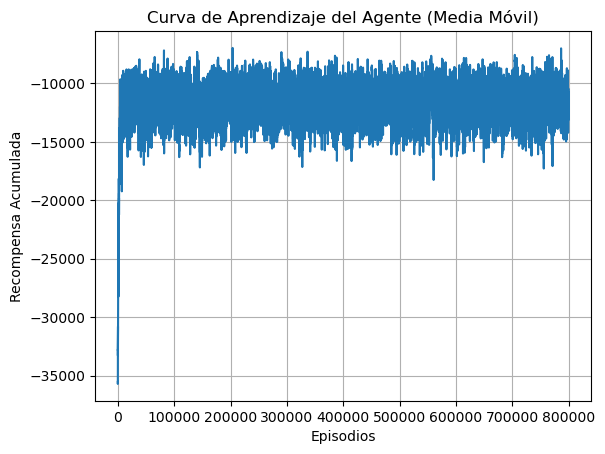

In [38]:
entorno = InterseccionLoaSilesAvanzada()
agente = AgenteQAvanzado(epsilon=1.0) # Empieza 100% exploratorio

episodios = 800000 
historial_recompensas = []

# Variables para decaimiento de exploración
epsilon_minimo = 0.05
tasa_decaimiento = 0.9995

print("Entrenando el modelo...")
for episodio in range(episodios):
    entorno.__init__()
    hora_random, minuto_random = random.randint(0, 23), random.randint(0, 59)
    estado = entorno.step(0, hora_random, minuto_random)[0] 
    recompensa_total = 0
    
    for paso in range(100):
        accion = agente.elegir_accion(estado)
        proximo_estado, recompensa = entorno.step(accion, hora_random, minuto_random)
        agente.aprender(estado, accion, recompensa, proximo_estado)
        estado = proximo_estado
        recompensa_total += recompensa
        
    historial_recompensas.append(recompensa_total)
    
    # El agente pierde el "miedo" gradualmente
    agente.epsilon = max(epsilon_minimo, agente.epsilon * tasa_decaimiento)

print("¡Entrenamiento finalizado!")
plt.plot(np.convolve(historial_recompensas, np.ones(200)/200, mode='valid'))
plt.title('Curva de Aprendizaje del Agente (Media Móvil)')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Acumulada')
plt.grid(True)
plt.show()

In [39]:
import pickle

with open('agente.pickle', 'wb') as handle:
    pickle.dump(agente, handle)

## 4. Validación (`X_prueba`)

Evaluamos la política óptima ($\pi_*$) ante un escenario de crisis: Hora Pico + Aparición de Ambulancia. El agente no debe explorar, sino explotar el modelo.

In [40]:
agente.epsilon = 0.0 # Apagar exploración

X_prueba = [
    {"bloque_horario": 0, "ambulancia": False, "nombre": "Tráfico Normal sin emergencias"},
    {"bloque_horario": 1, "ambulancia": True, "nombre": "CRISIS: Hora Pico + Ambulancia en Avenida"}
]

for escenario in X_prueba:
    entorno.__init__()
    estado = entorno.obtener_estado()
    entorno.ambulancia_presente = escenario["ambulancia"]
    
    castigo_total = 0
    for _ in range(50):
        accion = agente.elegir_accion(estado)
        estado, recompensa = entorno.step(accion, hora_actual=7 if escenario["bloque_horario"] == 1 else 14, minuto_actual=0)
        castigo_total += recompensa
        
    print(f"Resultado en {escenario['nombre']}: Castigo de {castigo_total}")


Resultado en Tráfico Normal sin emergencias: Castigo de -560
Resultado en CRISIS: Hora Pico + Ambulancia en Avenida: Castigo de -17455


## 4. Gemelo Digital Visual (Pygame)

Para validar la efectividad de la política aprendida ($\pi_*$), se despliega una simulación 2D orientada a eventos. El agente opera con un $\epsilon = 0.0$ (explotación total), enfrentándose a un ciclo de reloj continuo de 24 horas. Se incluye renderizado dinámico de colas, cálculo físico de llegada, y representación de eventos críticos.
*(Ejecutar localmente para renderizado a 60 FPS)*

In [42]:
import pygame
import random
import pickle

# --- 1. CARGAR EL CEREBRO DEL AGENTE ---
try:
    with open('agente_sucre.pickle', 'rb') as f:
        agente = pickle.load(f)
    print("¡Archivo pickle cargado correctamente!")
except FileNotFoundError:
    print("ERROR: No se encontró 'agente_sucre.pickle'.")

agente.epsilon = 0.0

# --- 2. INICIAR PYGAME ---
pygame.init()
pantalla = pygame.display.set_mode((800, 600))
pygame.display.set_caption("Gemelo Digital: Tráfico Interactivo")

NEGRO, ASFALTO, BLANCO = (20, 20, 20), (60, 60, 65), (240, 240, 240)
PAVIMENTO = (140, 140, 140)
LINEA_AMARILLA = (220, 180, 0)
VERDE_SEMAFORO, ROJO_SEMAFORO = (30, 255, 30), (255, 30, 30)
GRIS_OSCURO, COLOR_BOTON = (40, 40, 40), (100, 100, 120)

entorno_sim = InterseccionLoaSilesAvanzada()
reloj_pygame = pygame.time.Clock()

# --- FUNCIONES DE DIBUJO ---
def dibujar_paso_cebra(x, y, ancho, alto, lineas_verticales=True):
    if lineas_verticales:
        for i in range(0, ancho, 15): pygame.draw.rect(pantalla, BLANCO, (x + i, y, 8, alto))
    else:
        for i in range(0, alto, 15): pygame.draw.rect(pantalla, BLANCO, (x, y + i, ancho, 8))

def dibujar_auto_realista(x, y, orientacion, color=(40, 90, 180)):
    if orientacion == 'H':
        pygame.draw.rect(pantalla, (15, 15, 15), (x+4, y-2, 7, 20), border_radius=1) 
        pygame.draw.rect(pantalla, (15, 15, 15), (x+18, y-2, 7, 20), border_radius=1)
        chasis, techo = (x, y, 28, 16), (x+8, y+2, 11, 12)
        vidrio_del, vidrio_tras = (x+4, y+2, 4, 12), (x+20, y+2, 3, 12)
        faros, frenos = [(x, y+2, 2, 3), (x, y+11, 2, 3)], [(x+26, y+2, 2, 3), (x+26, y+11, 2, 3)]
    elif orientacion == 'V_ABAJO':
        pygame.draw.rect(pantalla, (15, 15, 15), (x-2, y+4, 20, 7), border_radius=1)
        pygame.draw.rect(pantalla, (15, 15, 15), (x-2, y+18, 20, 7), border_radius=1)
        chasis, techo = (x, y, 16, 28), (x+2, y+8, 12, 11)
        vidrio_del, vidrio_tras = (x+2, y+20, 12, 4), (x+2, y+4, 12, 3)
        faros, frenos = [(x+2, y+26, 3, 2), (x+11, y+26, 3, 2)], [(x+2, y, 3, 2), (x+11, y, 3, 2)]
    elif orientacion == 'V_ARRIBA':
        pygame.draw.rect(pantalla, (15, 15, 15), (x-2, y+4, 20, 7), border_radius=1)
        pygame.draw.rect(pantalla, (15, 15, 15), (x-2, y+18, 20, 7), border_radius=1)
        chasis, techo = (x, y, 16, 28), (x+2, y+9, 12, 11)
        vidrio_del, vidrio_tras = (x+2, y+4, 12, 4), (x+2, y+21, 12, 3)
        faros, frenos = [(x+2, y, 3, 2), (x+11, y, 3, 2)], [(x+2, y+26, 3, 2), (x+11, y+26, 3, 2)]

    pygame.draw.rect(pantalla, color, chasis, border_radius=4)
    pygame.draw.rect(pantalla, (max(0, color[0]-30), max(0, color[1]-30), max(0, color[2]-30)), techo, border_radius=2)
    pygame.draw.rect(pantalla, (30, 60, 90), vidrio_del) 
    pygame.draw.rect(pantalla, (30, 60, 90), vidrio_tras) 
    for f in faros: pygame.draw.rect(pantalla, (255, 255, 220), f)
    for f in frenos: pygame.draw.rect(pantalla, (200, 30, 30), f)

def dibujar_ambulancia_realista(x, y):
    pygame.draw.rect(pantalla, (10, 10, 10), (x-2, y+5, 22, 8), border_radius=2)
    pygame.draw.rect(pantalla, (10, 10, 10), (x-2, y+25, 22, 8), border_radius=2)
    pygame.draw.rect(pantalla, (245, 245, 245), (x-1, y, 20, 38), border_radius=3)
    pygame.draw.rect(pantalla, (220, 30, 30), (x+8, y, 4, 38)) 
    pygame.draw.rect(pantalla, (220, 30, 30), (x+4, y+16, 12, 4)) 
    pygame.draw.rect(pantalla, (200, 200, 200), (x+1, y+25, 16, 10), border_radius=2) 
    pygame.draw.rect(pantalla, (20, 50, 70), (x+1, y+32, 16, 5)) 
    if (pygame.time.get_ticks() % 600) < 300:
        pygame.draw.circle(pantalla, (255, 50, 50), (x+4, y+24), 4) 
        pygame.draw.circle(pantalla, (255, 50, 50, 100), (x+4, y+24), 15, 1) 
    else:
        pygame.draw.circle(pantalla, (50, 100, 255), (x+14, y+24), 4) 
        pygame.draw.circle(pantalla, (50, 100, 255, 100), (x+14, y+24), 15, 1)

# --- VARIABLES DE SIMULACIÓN ---
corriendo = True
contador_frames = 0
horas_sim, minutos_sim, segundos_sim = 7, 29, 50 

pos_visual_loa, pos_visual_mercado, pos_visual_parque = [], [], []
autos_cruzando = []
colores_autos = [(40, 90, 180), (180, 40, 40), (40, 180, 90), (150, 150, 150), (200, 180, 40)]

autos_procesados_hora = 0
hora_anterior = horas_sim

pos_visual_ambulancia = -100 
ambulancias_cruzando = []

btn_loa = pygame.Rect(650, 180, 100, 30)
btn_mercado = pygame.Rect(180, 50, 100, 30)
btn_parque = pygame.Rect(520, 500, 100, 30)
btn_ambulancia = pygame.Rect(20, 80, 150, 35) 

fuente_btn = pygame.font.SysFont("Arial", 14, bold=True)
fuente_calle = pygame.font.SysFont("Arial", 26, bold=True)

while corriendo:
    for evento in pygame.event.get():
        if evento.type == pygame.QUIT: 
            corriendo = False
            
        if evento.type == pygame.MOUSEBUTTONDOWN and evento.button == 1:
            if btn_loa.collidepoint(evento.pos):
                entorno_sim.autos_loa = min(entorno_sim.autos_loa + 1, entorno_sim.max_loa)
            elif btn_mercado.collidepoint(evento.pos):
                entorno_sim.autos_mercado = min(entorno_sim.autos_mercado + 1, entorno_sim.max_siles)
            elif btn_parque.collidepoint(evento.pos):
                entorno_sim.autos_parque = min(entorno_sim.autos_parque + 1, entorno_sim.max_siles)
            elif btn_ambulancia.collidepoint(evento.pos):
                entorno_sim.ambulancia_presente = True

    pantalla.fill(NEGRO)
    estado_actual = entorno_sim.obtener_estado()
    
    contador_frames += 1
    if contador_frames >= 10: 
        segundos_sim += 1
        if segundos_sim >= 60:
            segundos_sim, minutos_sim = 0, minutos_sim + 1
            if minutos_sim >= 60:
                minutos_sim, horas_sim = 0, (horas_sim + 1) % 24
                
        accion_optima = agente.elegir_accion(estado_actual)
        
        fase_activa = estado_actual[3]
        t_verde = estado_actual[5]
        vieja_ambulancia = estado_actual[6] 
        
        if accion_optima == 1 and t_verde >= 5:
            fase_activa = (fase_activa + 1) % 3
            
        evacuados_loa = min(estado_actual[0], 1) if fase_activa == 0 else 0
        evacuados_mercado = min(estado_actual[1], 1) if fase_activa == 1 else 0
        evacuados_parque = min(estado_actual[2], 1) if fase_activa == 2 else 0

        autos_procesados_hora += (evacuados_loa + evacuados_mercado + evacuados_parque)

        # NUEVO: Generar los autos que van a cruzar 
        # (Nota que la 'x' original del carril mercado es 345)
        for i in range(evacuados_loa):
            autos_cruzando.append({'x': 500 + (i * 35), 'y': 235, 'tipo': 'H', 'color': colores_autos[random.randint(0,4)]})
        for i in range(evacuados_mercado):
            # Si hay ambulancia, los autos que cruzan también se pegan a la derecha (355)
            x_salida = 355 if entorno_sim.ambulancia_presente else 345
            autos_cruzando.append({'x': x_salida, 'y': 180 - (i * 35), 'tipo': 'V_ABAJO', 'color': colores_autos[random.randint(0,4)]})
        for i in range(evacuados_parque):
            autos_cruzando.append({'x': 445, 'y': 300 + (i * 35), 'tipo': 'V_ARRIBA', 'color': colores_autos[random.randint(0,4)]})

        _, _ = entorno_sim.step(accion_optima, horas_sim, minutos_sim)
        nuevo_estado = entorno_sim.obtener_estado()
        
        # VERIFICAR SI LA AMBULANCIA CRUZÓ ESTE TURNO
        if vieja_ambulancia == 1 and nuevo_estado[6] == 0:
            # La ambulancia cruza por la izquierda del carril (x=330)
            ambulancias_cruzando.append({'x': 330, 'y': pos_visual_ambulancia})
            pos_visual_ambulancia = -100 
        
        contador_frames = 0
        if horas_sim != hora_anterior:
            autos_procesados_hora = 0
            hora_anterior = horas_sim
        
    pygame.draw.rect(pantalla, ASFALTO, (300, 0, 200, 600)) 
    pygame.draw.rect(pantalla, ASFALTO, (0, 200, 800, 100)) 
    for i in range(0, 600, 40): pygame.draw.rect(pantalla, LINEA_AMARILLA, (398, i, 4, 20))
    
    dibujar_paso_cebra(500, 200, 20, 100, lineas_verticales=False) 
    dibujar_paso_cebra(280, 200, 20, 100, lineas_verticales=False) 
    dibujar_paso_cebra(300, 180, 200, 20, lineas_verticales=True)  
    dibujar_paso_cebra(300, 300, 200, 20, lineas_verticales=True)  

    texto_loa = fuente_calle.render("CALLE LOA", True, PAVIMENTO)
    pantalla.blit(texto_loa, (550, 235)) 
    texto_siles = pygame.transform.rotate(fuente_calle.render("AV. HERNANDO SILES", True, PAVIMENTO), 90)
    pantalla.blit(texto_siles, (365, 380))

    fase = estado_actual[3]
    for sem, pos in [(fase==0, (270, 260)), (fase==1, (360, 325)), (fase==2, (420, 150))]:
        pygame.draw.rect(pantalla, GRIS_OSCURO, (pos[0]-5, pos[1]-5, 25, 25), border_radius=5)
        pygame.draw.circle(pantalla, VERDE_SEMAFORO if sem else ROJO_SEMAFORO, (pos[0]+7, pos[1]+7), 8)

    while len(pos_visual_loa) < entorno_sim.autos_loa: pos_visual_loa.append(850)
    while len(pos_visual_loa) > entorno_sim.autos_loa: pos_visual_loa.pop(0)
    while len(pos_visual_mercado) < entorno_sim.autos_mercado: pos_visual_mercado.append(-50)
    while len(pos_visual_mercado) > entorno_sim.autos_mercado: pos_visual_mercado.pop(0)
    while len(pos_visual_parque) < entorno_sim.autos_parque: pos_visual_parque.append(650)
    while len(pos_visual_parque) > entorno_sim.autos_parque: pos_visual_parque.pop(0)

    for i, pos in enumerate(pos_visual_loa):
        obj = 530 + (i * 32)
        if pos > obj: pos_visual_loa[i] -= 4
        dibujar_auto_realista(pos_visual_loa[i], 235, 'H', colores_autos[i % len(colores_autos)])
        
    for i, pos in enumerate(pos_visual_mercado):
        obj = 140 - (i * 32)
        if pos < obj: pos_visual_mercado[i] += 4
        
        # --- NUEVO: EFECTO DE HACERSE A UN LADO ---
        x_auto = 345 # Posición central normal
        # Si hay ambulancia Y el auto está delante de ella, el auto se hace a la derecha
        if entorno_sim.ambulancia_presente and pos_visual_mercado[i] > pos_visual_ambulancia:
            x_auto = 355 # Se pegan a la línea divisoria amarilla
            
        dibujar_auto_realista(x_auto, pos_visual_mercado[i], 'V_ABAJO', colores_autos[(i+2) % len(colores_autos)])
        
    for i, pos in enumerate(pos_visual_parque):
        obj = 330 + (i * 32)
        if pos > obj: pos_visual_parque[i] -= 4
        dibujar_auto_realista(445, pos_visual_parque[i], 'V_ARRIBA', colores_autos[(i+4) % len(colores_autos)])

    # --- LÓGICA DE DIBUJO DE LA AMBULANCIA ---
    if entorno_sim.ambulancia_presente:
        objetivo_ambulancia = 140 - (entorno_sim.autos_mercado * 32)
        if pos_visual_ambulancia < objetivo_ambulancia: 
            pos_visual_ambulancia += 4 
        elif pos_visual_ambulancia > objetivo_ambulancia:
            pos_visual_ambulancia -= 4 
            
        # NUEVO: La ambulancia se dibuja un poco más a la izquierda (x=330)
        dibujar_ambulancia_realista(330, pos_visual_ambulancia)

    # --- NUEVO: ANIMACIÓN DE CRUCE EN CÁMARA LENTA ---
    # Cambiamos la velocidad de 8 a 4 píxeles por frame para que sea muy notorio
    velocidad_cruce = 4
    for auto in autos_cruzando[:]:
        if auto['tipo'] == 'H': 
            auto['x'] -= velocidad_cruce; dibujar_auto_realista(auto['x'], auto['y'], 'H', auto['color'])
            if auto['x'] < 200: autos_cruzando.remove(auto)
        elif auto['tipo'] == 'V_ABAJO': 
            auto['y'] += velocidad_cruce; dibujar_auto_realista(auto['x'], auto['y'], 'V_ABAJO', auto['color'])
            if auto['y'] > 400: autos_cruzando.remove(auto)
        elif auto['tipo'] == 'V_ARRIBA': 
            auto['y'] -= velocidad_cruce; dibujar_auto_realista(auto['x'], auto['y'], 'V_ARRIBA', auto['color'])
            if auto['y'] < 100: autos_cruzando.remove(auto)

    for amb in ambulancias_cruzando[:]:
        amb['y'] += velocidad_cruce
        dibujar_ambulancia_realista(amb['x'], amb['y'])
        if amb['y'] > 600:
            ambulancias_cruzando.remove(amb)

    # --- PANEL DE TELEMETRÍA ---
    panel_rect = pygame.Rect(10, 400, 270, 180)
    pygame.draw.rect(pantalla, (25, 25, 30), panel_rect, border_radius=10)
    pygame.draw.rect(pantalla, (80, 80, 100), panel_rect, width=2, border_radius=10)

    pantalla.blit(pygame.font.SysFont("Arial", 18, bold=True).render("📊 TELEMETRÍA DE TRÁFICO", True, BLANCO), (20, 410))

    perfil = estado_actual[4]
    if perfil == 3: tasa_txt, color_tasa = "ALTA (Hora Pico)", ROJO_SEMAFORO
    elif perfil == 2: tasa_txt, color_tasa = "MEDIA (Trans.)", (220, 180, 0)
    elif perfil == 1: tasa_txt, color_tasa = "NORMAL (Día)", BLANCO
    else: tasa_txt, color_tasa = "BAJA (Noche)", VERDE_SEMAFORO

    fuente_stats = pygame.font.SysFont("Arial", 14)
    pantalla.blit(fuente_stats.render("Demanda del Entorno:", True, BLANCO), (20, 450))
    pantalla.blit(pygame.font.SysFont("Arial", 14, bold=True).render(tasa_txt, True, color_tasa), (160, 450))

    pantalla.blit(fuente_stats.render("Autos evacuados esta hora:", True, BLANCO), (20, 480))
    pantalla.blit(pygame.font.SysFont("Arial", 16, bold=True).render(str(autos_procesados_hora), True, (100, 255, 100)), (210, 478))

    pantalla.blit(fuente_stats.render("Densidad Actual de Intersección:", True, BLANCO), (20, 510))
    total_autos = estado_actual[0] + estado_actual[1] + estado_actual[2]
    max_autos = entorno_sim.max_loa + (entorno_sim.max_siles * 2)
    porcentaje = total_autos / max_autos
    
    pygame.draw.rect(pantalla, (50, 50, 50), (20, 535, 230, 15), border_radius=5)
    if total_autos > 0:
        color_barra = VERDE_SEMAFORO if porcentaje < 0.3 else (220, 180, 0) if porcentaje < 0.7 else ROJO_SEMAFORO
        pygame.draw.rect(pantalla, color_barra, (20, 535, int(230 * porcentaje), 15), border_radius=5)
    pantalla.blit(fuente_stats.render(f"{total_autos} / {max_autos} vehículos", True, BLANCO), (50, 555))

    # --- BOTONES Y HUD ---
    pygame.draw.rect(pantalla, COLOR_BOTON, btn_loa, border_radius=5)
    pygame.draw.rect(pantalla, COLOR_BOTON, btn_mercado, border_radius=5)
    pygame.draw.rect(pantalla, COLOR_BOTON, btn_parque, border_radius=5)
    pygame.draw.rect(pantalla, (200, 50, 50), btn_ambulancia, border_radius=5)
    
    pantalla.blit(fuente_btn.render("+1 Auto Loa", True, BLANCO), (btn_loa.x + 10, btn_loa.y + 6))
    pantalla.blit(fuente_btn.render("+1 Auto Siles", True, BLANCO), (btn_mercado.x + 5, btn_mercado.y + 6))
    pantalla.blit(fuente_btn.render("+1 Auto Siles", True, BLANCO), (btn_parque.x + 5, btn_parque.y + 6))
    pantalla.blit(fuente_btn.render("🚨 INYECTAR AMBULANCIA", True, BLANCO), (btn_ambulancia.x + 8, btn_ambulancia.y + 8))

    color_hud = ROJO_SEMAFORO if perfil == 3 else (220, 180, 0) if perfil in [1, 2] else VERDE_SEMAFORO
    texto_reloj = f"[{horas_sim:02d}:{minutos_sim:02d}:{segundos_sim:02d}]"
    pantalla.blit(pygame.font.SysFont("Courier", 32, bold=True).render(texto_reloj, True, color_hud), (610, 20))
    
    pygame.display.flip()
    reloj_pygame.tick(60) 

pygame.quit()

ERROR: No se encontró 'agente_sucre.pickle'.
